In [13]:
import pandas as pd
import itertools
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
comparisons=['bAmy-vs-CTR','CTR-Tau-vs-CTR','PCB118-vs-CTR','PCB153-vs-CTR']

/tmp/ipykernel_15748/3756699559.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
/tmp/ipykernel_15748/3756699559.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
/tmp/ipykernel_15748/3756699559.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(
/tmp/ipykernel_15748/3756699559.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


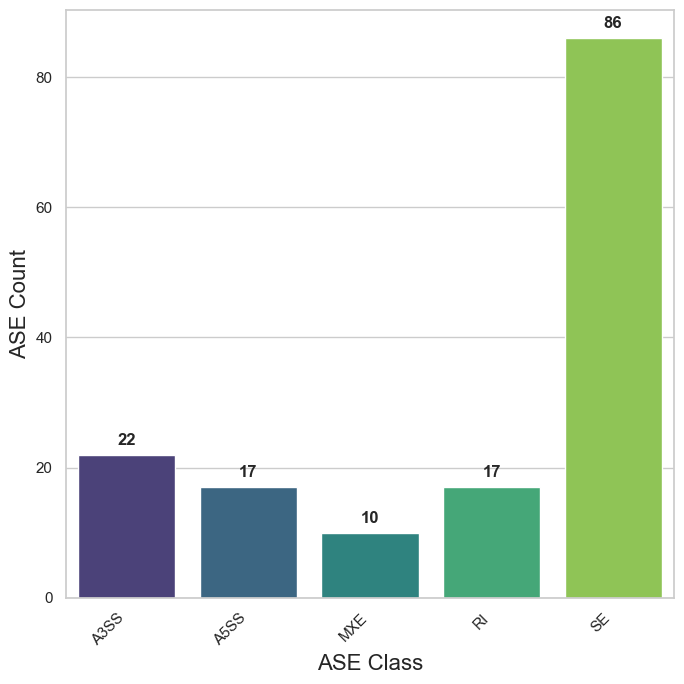

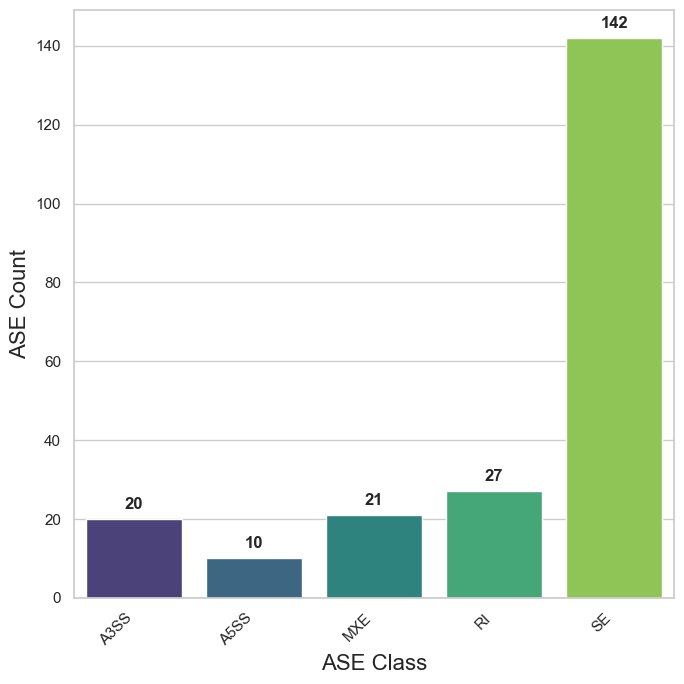

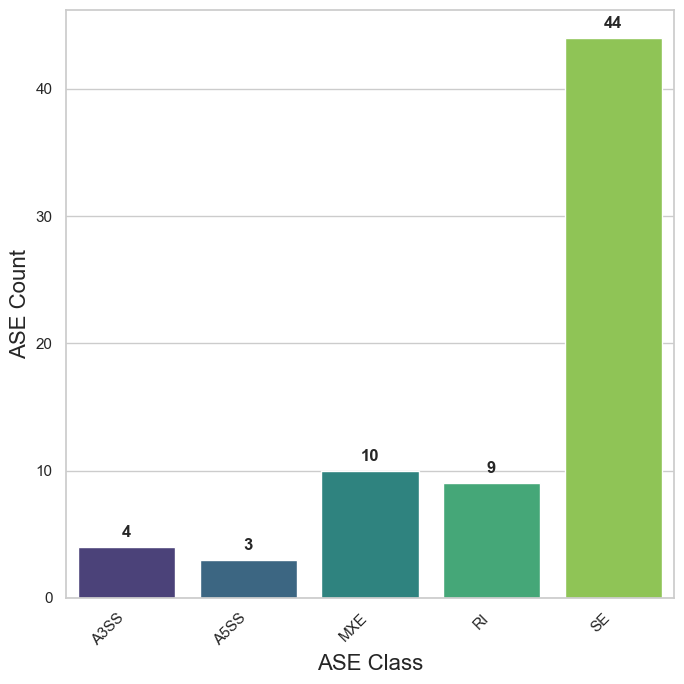

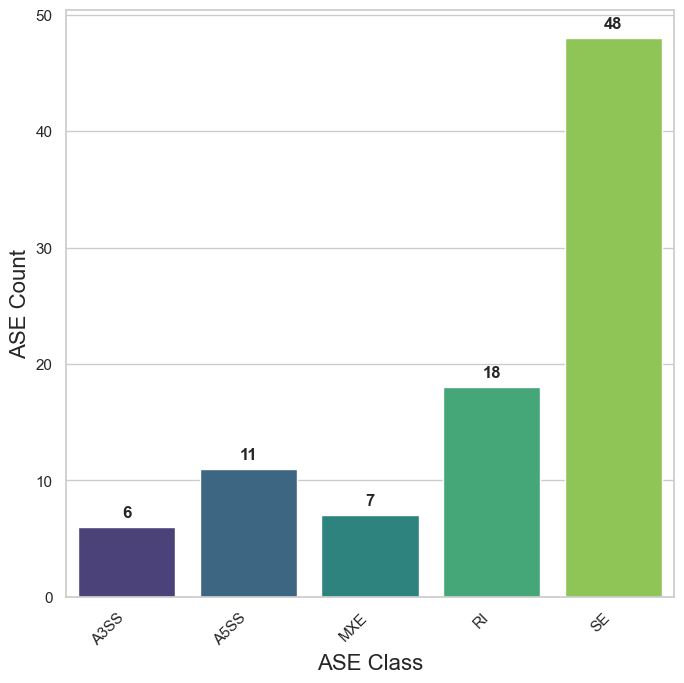

In [4]:
for comp in comparisons:
    # Make directory if it doesn't exist
    outdir = f"{comp}/figures"
    os.makedirs(outdir, exist_ok=True)
    dase = pd.read_csv(f"{comp}/DASE/de_novo_annotated_DASE_{comp}.txt", sep='\t')
    # Group data
    df_counts = dase.groupby(['Class']).size().reset_index(name='Count')

    # Set seaborn theme
    sns.set_theme(style='whitegrid')

    # Plotting
    plt.figure(figsize=(7, 7))
    barplot = sns.barplot(
        data=df_counts,
        x='Class',
        y='Count',
        palette='viridis'
    )

# Add value labels on top of bars
    for p in barplot.patches:
        count = int(p.get_height())
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        barplot.annotate(
            f'{count}',
            (x, y),
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold',
            xytext=(0, 5),  # small offset above bar
            textcoords='offset points'
        )

# Formatting
    plt.xticks(rotation=45, ha='right', fontsize=11)
    plt.yticks(fontsize=11)
    plt.xlabel('ASE Class', fontsize=16)
    plt.ylabel('ASE Count', fontsize=16)
    plt.tight_layout()

# Save & Show
    plt.savefig(outdir+'/ASE_count_per_class_with_values.png', dpi=300, bbox_inches='tight',transparent=True )